<a href="https://colab.research.google.com/github/zyf-hitsz/PytorchLearning/blob/main/_downloads/36608d2d57f623ba3a623e0c947a8c3e/data_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

这个笔记本将一个最简单的模型训练的实际训练部分删掉了，展示了我们应该怎样获取、预处理信息，并得到训练中的数据。



Datasets & DataLoaders
======================


Code for processing data samples can get messy and hard to maintain; we
ideally want our dataset code to be decoupled from our model training
code for better readability and modularity. PyTorch provides two data
primitives: `torch.utils.data.DataLoader` and `torch.utils.data.Dataset`
that allow you to use pre-loaded datasets as well as your own data.
`Dataset` stores the samples and their corresponding labels, and
`DataLoader` wraps an iterable around the `Dataset` to enable easy
access to the samples.

PyTorch domain libraries provide a number of pre-loaded datasets (such
as FashionMNIST) that subclass `torch.utils.data.Dataset` and implement
functions specific to the particular data. They can be used to prototype
and benchmark your model. You can find them here: [Image
Datasets](https://pytorch.org/vision/stable/datasets.html), [Text
Datasets](https://pytorch.org/text/stable/datasets.html), and [Audio
Datasets](https://pytorch.org/audio/stable/datasets.html)


Loading a Dataset
=================

Here is an example of how to load the
[Fashion-MNIST](https://research.zalando.com/project/fashion_mnist/fashion_mnist/)
dataset from TorchVision. Fashion-MNIST is a dataset of Zalando's
article images consisting of 60,000 training examples and 10,000 test
examples. Each example comprises a 28×28 grayscale image and an
associated label from one of 10 classes.

We load the [FashionMNIST Dataset](https://pytorch.org/vision/stable/datasets.html#fashion-mnist) with the following parameters:

:   -   `root` is the path where the train/test data is stored,
    -   `train` specifies training or test dataset,
    -   `download=True` downloads the data from the internet if it\'s
        not available at `root`.
    -   `transform` and `target_transform` specify the feature and label
        transformations


In [11]:
import torch
from torch.utils.data import Dataset#导入 Dataset 基类。在 PyTorch 中，通过继承这个类可以创建自定义的数据集，用于存储样本及其对应的标签。
from torchvision import datasets#torchvision 是 PyTorch 的计算机视觉库。这里导入 datasets 模块是为了使用它提供的内置常用数据集
from torchvision.transforms import v2#导入 torchvision 的最新数据转换模块。它用于对图像进行预处理
import matplotlib.pyplot as plt#导入 Matplotlib 的绘图模块，主要用于将数据集中的图像可视化展示出来。


training_data = datasets.FashionMNIST(#通过 datasets.FashionMNIST 类来加载经典的数据集
    root="data",#指定数据集存储的本地路径。如果数据集已存在，它会从这里加载；如果不存在（且 download=True），则会下载到此目录
    train=True,#加载 训练集
    download=True,# 如果指定的 root 目录下没有数据，会自动从官方服务器下载数据
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
    #transform 参数定义了图像进入模型前的处理流程。这里使用了 v2.Compose 将多个操作按顺序组合：
    #v2.ToImage(): 将原始的 PIL 图像或 numpy 数组转换为 PyTorch 图像对象。
    #v2.ToDtype(torch.float32, scale=True):
    #将数据类型转为 float32（深度学习模型通常要求的输入类型）。
    #scale=True 非常关键：它会自动将像素值从 [0, 255] 归一化（缩放）到 [0, 1] 之间，这有助于模型更快收敛。
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

Iterating and Visualizing the Dataset
=====================================

We can index `Datasets` manually like a list: `training_data[index]`. We
use `matplotlib` to visualize some samples in our training data.


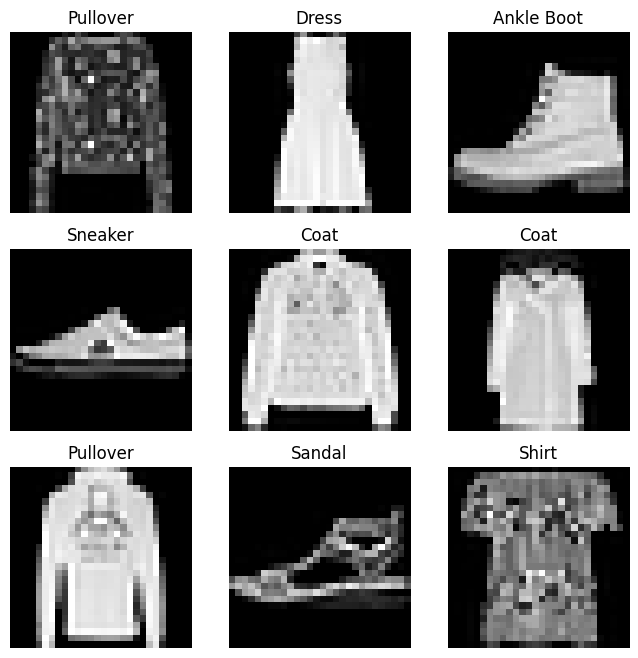

In [12]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}#将图片类型映射到数字标签
figure = plt.figure(figsize=(8, 8))#创建8*8画布
cols, rows = 3, 3#设置三行三列
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()#随机生成索引
    img, label = training_data[sample_idx]#根据索引获取图像数据和标签
    figure.add_subplot(rows, cols, i)#设置图片位置
    plt.title(labels_map[label])#设置标题
    plt.axis("off")#取消坐标轴
    plt.imshow(img.squeeze(), cmap="gray")#渲染图片为灰度图
plt.show()

------------------------------------------------------------------------


Creating a Custom Dataset for your files
========================================

A custom Dataset class must implement three functions:
[\_\_init\_\_]{.title-ref}, [\_\_len\_\_]{.title-ref}, and
[\_\_getitem\_\_]{.title-ref}. Take a look at this implementation; the
FashionMNIST images are stored in a directory `img_dir`, and their
labels are stored separately in a CSV file `annotations_file`.

In the next sections, we\'ll break down what\'s happening in each of
these functions.


In [13]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):#定义一个名为 CustomImageDataset 的类，，它继承自 PyTorch 的 Dataset 基类。
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):#初始化方法
        self.img_labels = pd.read_csv(annotations_file)#使用 pandas 读取存储文件名和标签的 CSV 文件，并保存到 self.img_labels 中。
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform
#将传入的参数保存为类的成员变量，以便在其他方法中使用。

    def __len__(self):#返回数据集的总样本数
        return len(self.img_labels)

    def __getitem__(self, idx):#根据给定的索引 idx 加载并返回一个样本。
        #它会根据索引拼接图像路径、读取图像、获取对应的标签，并根据需要应用图像或标签的转换，
        #最后返回一个 (image, label) 元组。
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])#根据索引从表格中获取文件名，并与图片目录路径拼接成完整的磁盘路径。
        image = decode_image(img_path)#使用 torchvision.io 中的函数将磁盘上的图片读取并解码为 PyTorch 张量（Tensor）。
        label = self.img_labels.iloc[idx, 1]#从表格的第二列中获取该样本对应的类别标签。
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

1.self. 的含义

在Python的类（Class）中，self 代表的是类的实例对象本身。

self.xxx：表示将一个变量绑定到这个实例上，使其成为“成员变量”。
作用：在 __init__ 方法中使用 self.img_labels = ...，是为了让其他方法（如 __len__ 和 __getitem__）也能够访问到这些数据。如果没有 self.，该变量就只是 __init__ 内部的一个局部变量，函数执行完就会被销毁。

2.transform 和 target_transform 的含义

这两个参数通常用于对原始数据进行预处理：

transform (图像转换)：

针对特征数据（在这里是图片）。
作用：将原始图片（如 PIL 图像或磁盘上的张量）转换为模型需要的格式。常见的操作包括：调整尺寸（Resize）、转为张量（ToTensor）、标准化（Normalize）或数据增强（如随机裁剪、翻转）。

target_transform (标签转换)：

针对标签数据（在这里是数字或类别名）。
作用：对标签进行处理。虽然不常用，但有时需要将类别索引转换为 One-Hot 编码，或者将字符串标签转换为数字索引。

`__init__`
==========

The \_\_[init](#init__) function is run once when instantiating the
Dataset object. We initialize the directory containing the images, the
annotations file, and both transforms (covered in more detail in the
next section).

The labels.csv file looks like: :

    tshirt1.jpg, 0
    tshirt2.jpg, 0
    ......
    ankleboot999.jpg, 9


`__len__`
=========

The \_\_[len](#len__) function returns the number of samples in our
dataset.

Example:


`__getitem__`
=============

The \_\_[getitem](#getitem__) function loads and returns a sample from
the dataset at the given index `idx`. Based on the index, it identifies
the image\'s location on disk, converts that to a tensor using
`decode_image`, retrieves the corresponding label from the csv data in
`self.img_labels`, calls the transform functions on them (if
applicable), and returns the tensor image and corresponding label in a
tuple.


------------------------------------------------------------------------


Preparing your data for training with DataLoaders
=================================================

The `Dataset` retrieves our dataset\'s features and labels one sample at
a time. While training a model, we typically want to pass samples in
\"minibatches\", reshuffle the data at every epoch to reduce model
overfitting, and use Python\'s `multiprocessing` to speed up data
retrieval.

`DataLoader` is an iterable that abstracts this complexity for us in an
easy API.


In [14]:
from torch.utils.data import DataLoader
#使用 PyTorch 的 DataLoader 来封装数据集，以便在训练模型时高效地读取数据。

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)#指定要加载的数据集对象
#batch_size=64: 批大小。这意味着每次迭代时，DataLoader 会返回 64 个样本。
#在深度学习中，我们通常按“批”处理数据，而不是一次只处理一个样本，这样可以充分利用 GPU 的并行计算能力。
#shuffle=True: 打乱数据,防止过拟合
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)#为测试集创建迭代器，便于在训练循环中成批地获取数据

Iterate through the DataLoader
==============================

We have loaded that dataset into the `DataLoader` and can iterate
through the dataset as needed. Each iteration below returns a batch of
`train_features` and `train_labels` (containing `batch_size=64` features
and labels respectively). Because we specified `shuffle=True`, after we
iterate over all batches the data is shuffled (for finer-grained control
over the data loading order, take a look at
[Samplers](https://pytorch.org/docs/stable/data.html#data-loading-order-and-sampler)).


Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


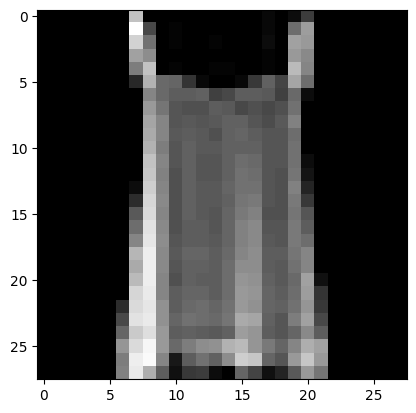

Label: 0


In [15]:
# Display image and label.
# 如何从 DataLoader 中提取并查看一个批次（Batch）的数据
train_features, train_labels = next(iter(train_dataloader))#从迭代器中获取第一个批次的数据
print(f"Feature batch shape: {train_features.size()}")#输出特征批次的维度
print(f"Labels batch shape: {train_labels.size()}")#输出标签的维度
img = train_features[0].squeeze()#取出该批次中的第一张图片，squeeze:移除维度中大小为1的维度，以便正常渲染
label = train_labels[0]#获取该批次中第一个样本对应的标签
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

------------------------------------------------------------------------


Further Reading
===============

-   [torch.utils.data API](https://pytorch.org/docs/stable/data.html)
